In [1]:
import gspread
from google.colab import auth
from google.auth import default
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import auth
import gspread
from google.auth import default

# Authenticate
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# BFS

In [2]:
# 1. Load the dataspreadsheet_name = "pr-bfs-scaling-vldb"
spreadsheet_name = "pr-bfs-scaling-vldb"
sh = gc.open(spreadsheet_name)
worksheet = sh.worksheet("BFS")

data = worksheet.get_all_values()
df = pd.DataFrame(data)

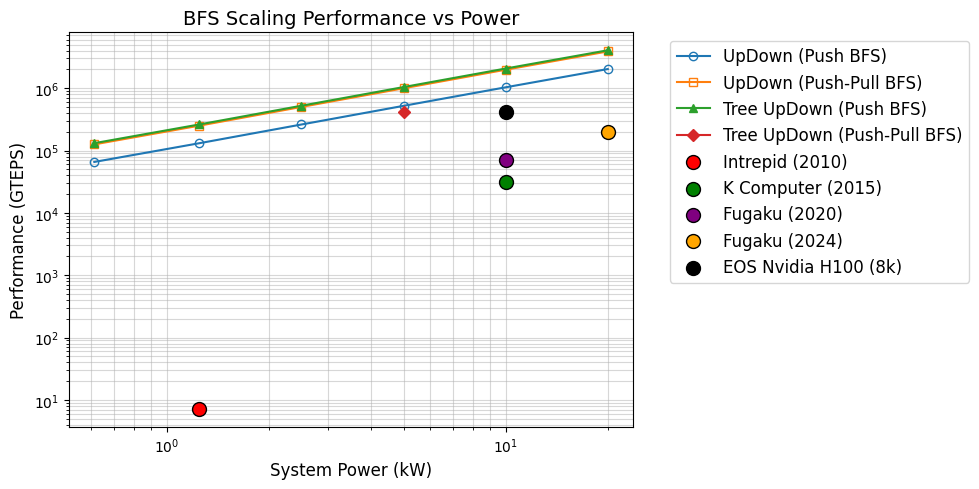

In [ ]:
# @title
# 2. Extract X-axis (System Power in kW)
# Row 0 (index 0), Columns 2-6 contain the power values
x_power = pd.to_numeric(df.iloc[0, 1:7]).astype(float).values

# 3. Extract Data Series
# Historical / Comparison Points
historical_data = {
    "Intrepid (2010)": (1.25, 7.1),
    "K Computer (2015)": (10, 31302),
    "Fugaku (2020)": (10, 70980),
    "Fugaku (2024)": (20, 200000),
    "EOS Nvidia H100 (8k)": (10, 410000)
}

# UpDown Architectures (Line Plots)
# Row 9: UpDown (Push BFS)
updown_push = df.iloc[9, 1:7].astype(float).values
# Row 10: UpDown (Push-Pull BFS)
updown_pp = df.iloc[10, 1:7].astype(float).values
# Row 11: Tree UpDown (Push-BFS)
tree_updown_push = df.iloc[11, 1:7].astype(float).values
# Row 12: Tree UpDown (Push-Pull-BFS)
tree_updown_pp = pd.to_numeric(df.iloc[12, 1:7]).astype(float).values

# 4. Create the Plot
plt.figure(figsize=(10, 5))

# Plot lines for UpDown configs
plt.plot(x_power, updown_push, 'o-', label='UpDown (Push BFS)', markerfacecolor='none')
plt.plot(x_power, updown_pp, 's-', label='UpDown (Push-Pull BFS)', markerfacecolor='none')
plt.plot(x_power, tree_updown_push, '^-', label='Tree UpDown (Push BFS)')
plt.plot(x_power, tree_updown_pp, 'D-', label='Tree UpDown (Push-Pull BFS)')

# Plot historical scatter points
colors = ['red', 'green', 'purple', 'orange', 'black']
for (name, (p, g)), color in zip(historical_data.items(), colors):
    plt.scatter(p, g, label=name, color=color, s=100, edgecolors='black', zorder=5)

# 5. Formatting
plt.xscale('log')
plt.yscale('log')
plt.xlabel('System Power (kW)', fontsize=12)
plt.ylabel('Performance (GTEPS)', fontsize=12)
plt.title('BFS Scaling Performance vs Power', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()

plt.show()

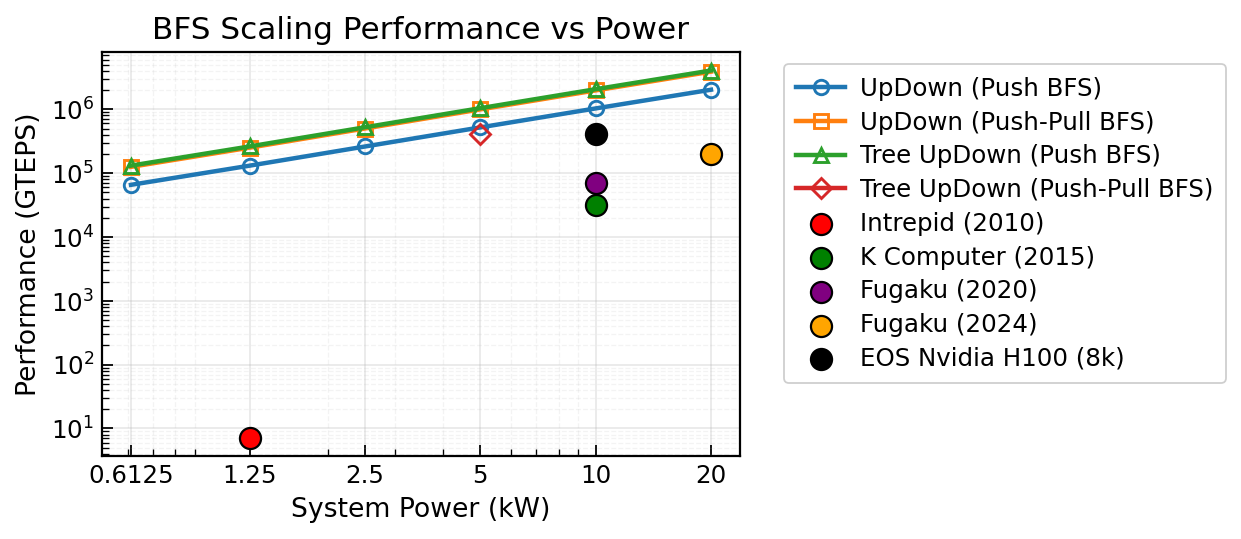

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

# ---------- (optional) paper-ish defaults, very light ----------
plt.rcParams.update({
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

# @title
# 2. Extract X-axis (System Power in kW)
x_power = pd.to_numeric(df.iloc[0, 1:7], errors="coerce").astype(float).values

# 3. Extract Data Series
historical_data = {
    "Intrepid (2010)": (1.25, 7.1),
    "K Computer (2015)": (10, 31302),
    "Fugaku (2020)": (10, 70980),
    "Fugaku (2024)": (20, 200000),
    "EOS Nvidia H100 (8k)": (10, 410000)
}

updown_push = pd.to_numeric(df.iloc[9, 1:7], errors="coerce").astype(float).values
updown_pp = pd.to_numeric(df.iloc[10, 1:7], errors="coerce").astype(float).values
tree_updown_push = pd.to_numeric(df.iloc[11, 1:7], errors="coerce").astype(float).values
tree_updown_pp = pd.to_numeric(df.iloc[12, 1:7], errors="coerce").astype(float).values

# 4. Create the Plot (keep your figsize and overall layout)
plt.figure(figsize=(8, 3.5))
ax = plt.gca()

# Consistent line style (paper-like but minimal change)
line_kw = dict(linewidth=2.0, markersize=6.5, markeredgewidth=1.3)

ax.plot(x_power, updown_push, 'o-', label='UpDown (Push BFS)',
        markerfacecolor='none', **line_kw)
ax.plot(x_power, updown_pp, 's-', label='UpDown (Push-Pull BFS)',
        markerfacecolor='none', **line_kw)
ax.plot(x_power, tree_updown_push, '^-', label='Tree UpDown (Push BFS)',
        markerfacecolor='none', **line_kw)
ax.plot(x_power, tree_updown_pp, 'D-', label='Tree UpDown (Push-Pull BFS)',
        markerfacecolor='none', **line_kw)

# Plot historical scatter points (keep your colors, make them print/zoom friendly)
colors = ['red', 'green', 'purple', 'orange', 'black']
for (name, (p, g)), color in zip(historical_data.items(), colors):
    ax.scatter(
        p, g,
        label=name,
        color=color,
        s=90,
        edgecolors='black',
        linewidths=1.0,
        zorder=5
    )

# 5. Formatting (same as yours, but more paper-like details)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('System Power (kW)', fontsize=12)
ax.set_ylabel('Performance (GTEPS)', fontsize=12)
ax.set_title('BFS Scaling Performance vs Power', fontsize=14)

# ---- custom x ticks (paper-friendly) ----
x_ticks = [0.6125, 1.25, 2.5, 5, 10, 20]
ax.set_xticks(x_ticks)
ax.set_xticklabels(['0.6125', '1.25', '2.5', '5', '10', '20'])


# Better log ticks (minor ticks for readability, no minor labels)
# ax.xaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_minor_formatter(NullFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())

# Grid: lighter + separate major/minor (looks more like papers)
ax.grid(True, which="major", ls="-", alpha=0.28, linewidth=0.8)
ax.grid(True, which="minor", ls="--", alpha=0.14, linewidth=0.6)

# Legend: keep your placement, but tighter box
leg = ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=11,
    frameon=True,
    borderpad=0.5,
    labelspacing=0.4,
    handlelength=2.0,
    handletextpad=0.6
)
leg.get_frame().set_linewidth(0.8)
leg.get_frame().set_alpha(0.95)

plt.tight_layout()

# (Optional) best for papers: vector output
plt.savefig("bfs_scaling.pdf", bbox_inches="tight")
# plt.savefig("bfs_power_scaling.svg", bbox_inches="tight")

plt.show()


# PageRank

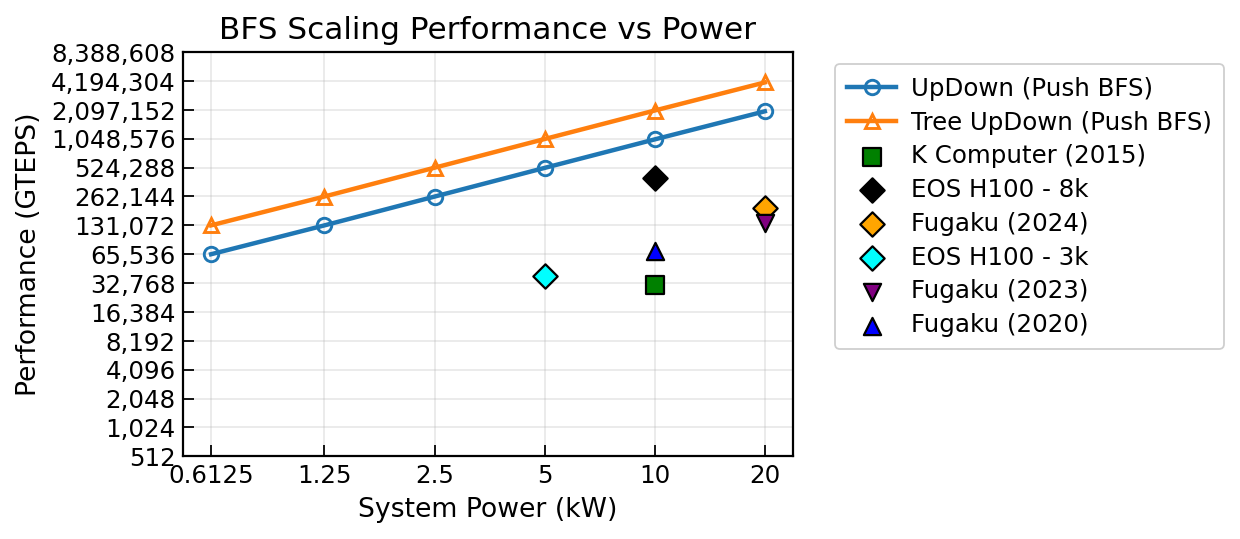

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import matplotlib.ticker as ticker

# ---------- (optional) paper-ish defaults, very light ----------
plt.rcParams.update({
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

# @title
# 2. Extract X-axis (System Power in kW)
x_power = pd.to_numeric(df.iloc[0, 1:7], errors="coerce").astype(float).values

# 3. Extract Data Series
historical_data = {
    ("K Computer (2015)", 10.0, 31302, 'green', 's'),
    ("Fugaku (2020)", 10.0, 70980, 'blue', '^'),
    ("Fugaku (2023)", 20.0, 138867, 'purple', 'v'),
    ("Fugaku (2024)", 20.0, 200000, 'orange', 'D'),
    ("EOS H100 - 3k", 5.0, 39085, 'cyan', 'D'),
    ("EOS H100 - 8k", 10.0, 410000, 'black', 'D')
}



# 4. Create the Plot (keep your figsize and overall layout)
plt.figure(figsize=(8, 3.5))
ax = plt.gca()

# Consistent line style (paper-like but minimal change)
line_kw = dict(linewidth=2.0, markersize=6.5, markeredgewidth=1.3)

ax.plot(x_power, updown_push, 'o-', label='UpDown (Push BFS)',
        markerfacecolor='none', **line_kw)
# ax.plot(x_power, updown_pp, 's-', label='UpDown (Push-Pull BFS)',
#         markerfacecolor='none', **line_kw)
ax.plot(x_power, tree_updown_push, '^-', label='Tree UpDown (Push BFS)',
        markerfacecolor='none', **line_kw)
# ax.plot(x_power, tree_updown_pp, 'D-', label='Tree UpDown (Push-Pull BFS)',
#         markerfacecolor='none', **line_kw)

# Plot historical scatter points (keep your colors, make them print/zoom friendly)
for name, x, y, color, marker in historical_data:
    ax.scatter(
        x, y,
        label=name,
        color=color,
        s=60,
        edgecolors='black',
        linewidths=1.0,
        zorder=5,
        marker=marker
    )


# 5. Formatting (same as yours, but more paper-like details)


ax.set_xscale('log', base=10)
ax.set_yscale('log', base=2)
ax.set_xlabel('System Power (kW)', fontsize=12)
ax.set_ylabel('Performance (GTEPS)', fontsize=12)
ax.set_title('BFS Scaling Performance vs Power', fontsize=14)

# ---- custom x ticks (paper-friendly) ----
x_ticks = [0.6125, 1.25, 2.5, 5, 10, 20]
ax.set_xticks(x_ticks)
ax.set_xticklabels(['0.6125', '1.25', '2.5', '5', '10', '20'])


# Set Y limits and horizontal grid to Power of 2
y_min_val = 512 # Set min y to 512 (2^9)
y_max_val = 4.2e6 # Top range for 8k H100
ax.set_ylim(bottom=y_min_val)
ax.xaxis.set_minor_locator(ticker.NullLocator())

# Define ticks at exact power of 2 intervals
y_min_pow = int(np.log2(y_min_val))
y_max_pow = int(np.ceil(np.log2(y_max_val)))
y_ticks = [2**i for i in range(y_min_pow, y_max_pow + 1)]
ax.set_yticks(y_ticks)

# Formatter for y-axis labels
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))


# Better log ticks (minor ticks for readability, no minor labels)
# ax.xaxis.set_major_locator(LogLocator(base=10))
# ax.yaxis.set_major_locator(LogLocator(base=10))
# ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 20) * 0.1))
# ax.yaxis.set_minor_locator(LogLocator(base=2, subs=np.arange(2, 10) * 0.1))
# ax.xaxis.set_minor_formatter(NullFormatter())
# ax.yaxis.set_minor_formatter(NullFormatter())

# Grid: lighter + separate major/minor (looks more like papers)
ax.grid(True, which="major", ls="-", alpha=0.28, linewidth=0.8)
# ax.grid(True, which="minor", ls="--", alpha=0.14, linewidth=0.6)

# Legend: keep your placement, but tighter box
leg = ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=11,
    frameon=True,
    borderpad=0.5,
    labelspacing=0.4,
    handlelength=2.0,
    handletextpad=0.6
)
leg.get_frame().set_linewidth(0.8)
leg.get_frame().set_alpha(0.95)

plt.tight_layout()

# (Optional) best for papers: vector output
plt.savefig("bfs_power_scaling.pdf", bbox_inches="tight")
# plt.savefig("bfs_power_scaling.svg", bbox_inches="tight")

plt.show()



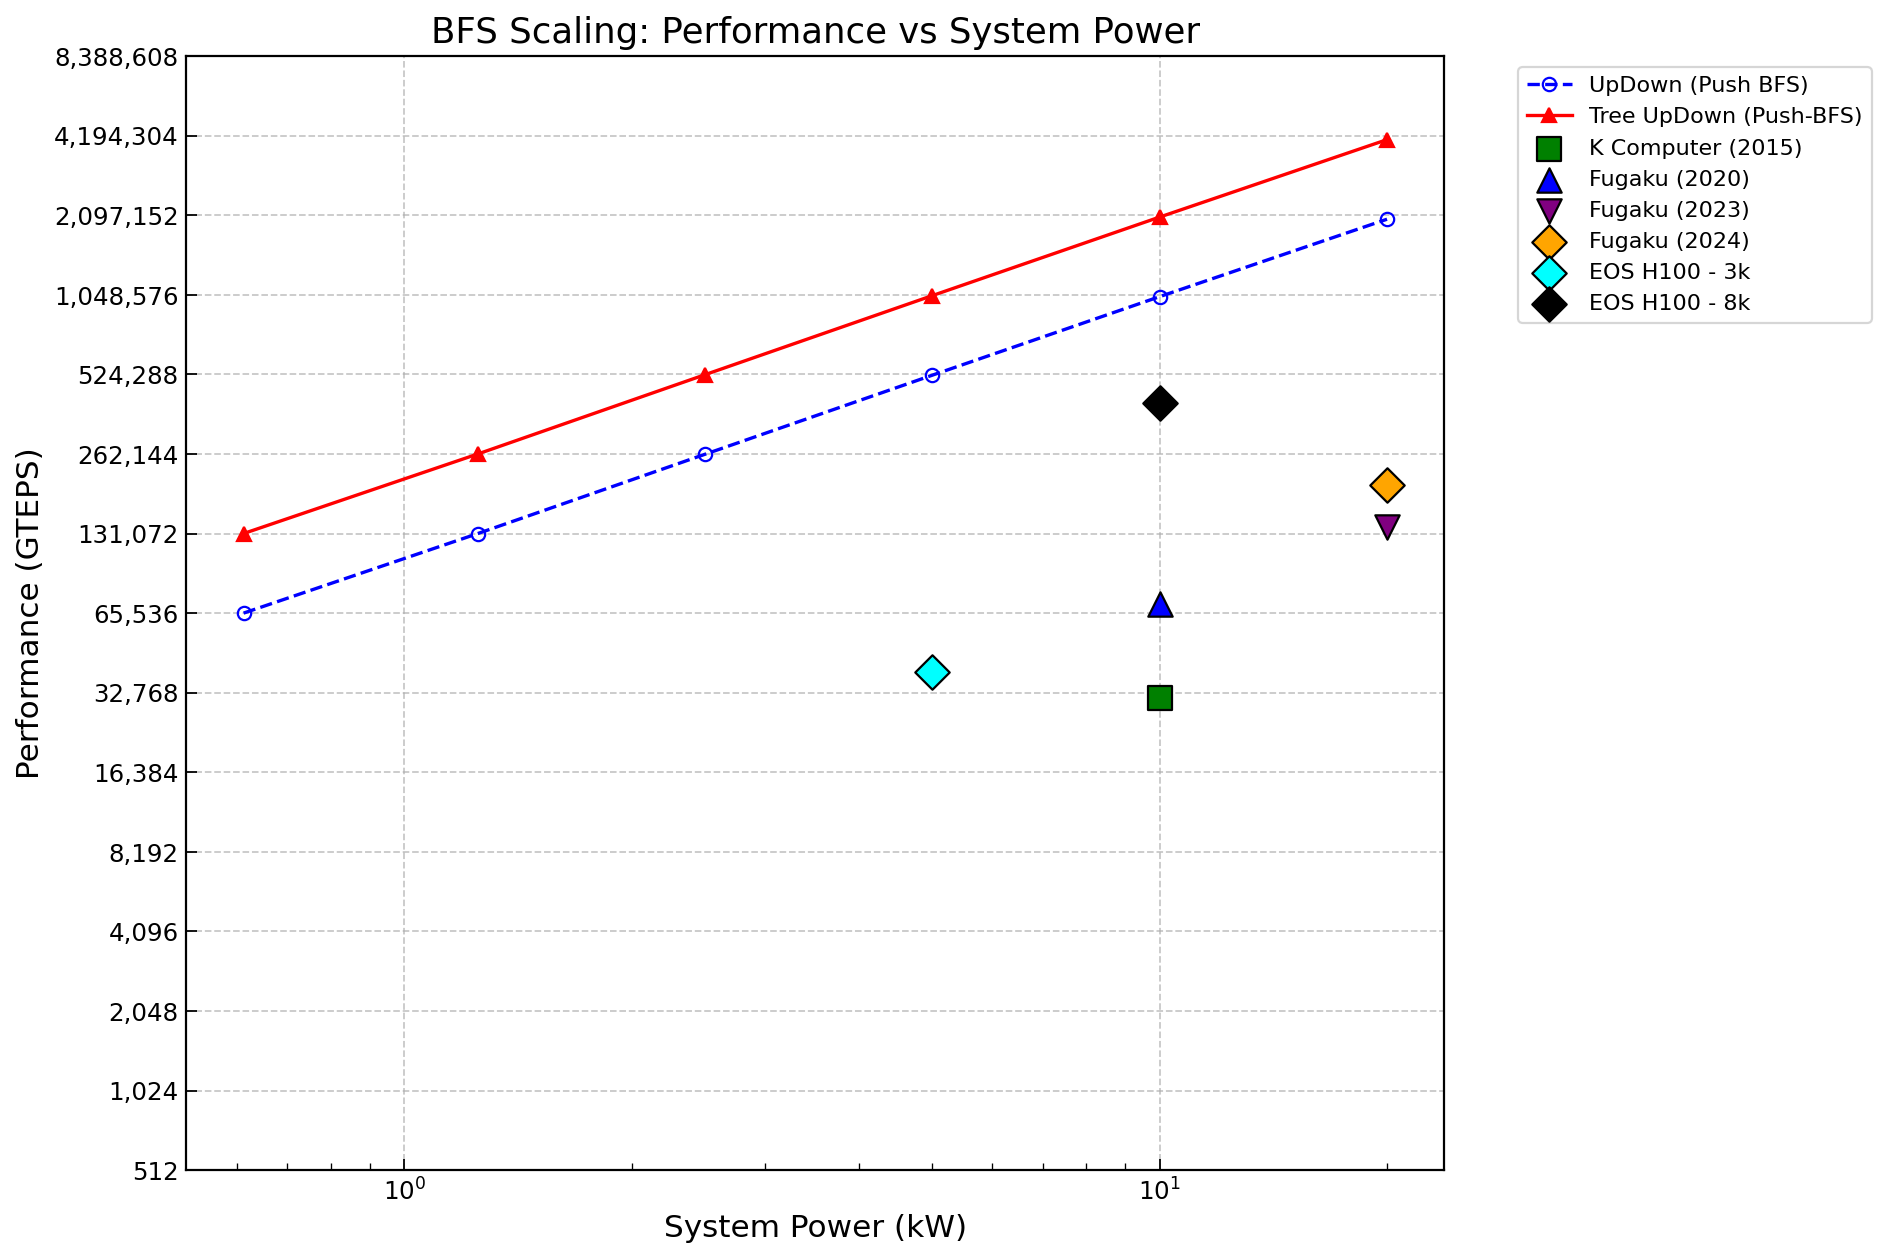

<Figure size 1024x768 with 0 Axes>

In [ ]:

# Historical points (Intrepid removed)
historical = [
    ("K Computer (2015)", 10.0, 31302, 'green', 's'),
    ("Fugaku (2020)", 10.0, 70980, 'blue', '^'),
    ("Fugaku (2023)", 20.0, 138867, 'purple', 'v'),
    ("Fugaku (2024)", 20.0, 200000, 'orange', 'D'),
    ("EOS H100 - 3k", 5.0, 39085, 'cyan', 'D'),
    ("EOS H100 - 8k", 10.0, 410000, 'black', 'D')
]

# 3. Create the Plot
plt.figure(figsize=(12, 8))

# Plot lines
plt.plot(x_power, updown_push, 'o--', label='UpDown (Push BFS)', markerfacecolor='none', color='blue')
# plt.plot(x_power, updown_pp, 's--', label='UpDown (Push-Pull BFS)', markerfacecolor='none', color='green')
plt.plot(x_power, tree_updown_push, '^-', label='Tree UpDown (Push-BFS)', color='red')
# plt.plot(x_power, tree_updown_pp, 'D-', label='Tree UpDown (Push-Pull-BFS)', color='purple')

# Plot historical points
for name, x, y, color, marker in historical:
    plt.scatter(x, y, label=name, color=color, marker=marker, s=120, edgecolors='black', zorder=5)

# 4. Configure Log Axes
plt.xscale('log', base=10)
plt.yscale('log', base=2)

# 5. Set Y limits and horizontal grid to Power of 2
y_min_val = 512 # Set min y to 512 (2^9)
y_max_val = 4.2e6 # Top range for 8k H100
plt.ylim(bottom=y_min_val)

# Define ticks at exact power of 2 intervals
y_min_pow = int(np.log2(y_min_val))
y_max_pow = int(np.ceil(np.log2(y_max_val)))
y_ticks = [2**i for i in range(y_min_pow, y_max_pow + 1)]
plt.yticks(y_ticks)

# Formatter for y-axis labels
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))

# 6. Formatting Labels and Grid
plt.xlabel('System Power (kW)', fontsize=14)
plt.ylabel('Performance (GTEPS)', fontsize=14)
plt.title('BFS Scaling: Performance vs System Power', fontsize=16)

plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.7)
plt.grid(True, which='major', axis='x', linestyle='--', alpha=0.7)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()

plt.show()
plt.savefig("bfs-scaling.pdf", format="pdf", bbox_inches="tight")


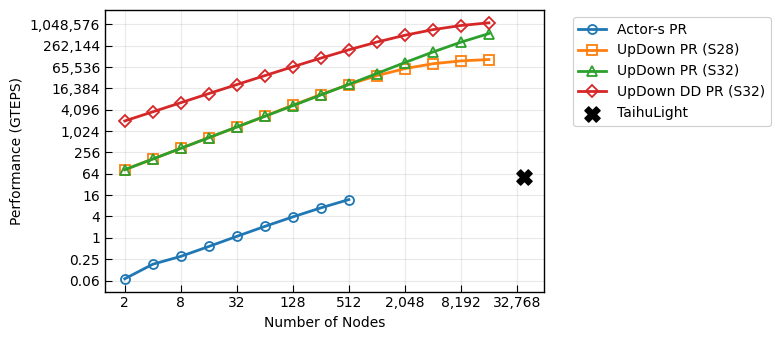

2      0.07
3      0.18
4       0.3
5      0.57
6       1.1
7       2.1
8       3.9
9         7
10       12
11    GTEPS
12    Ratio
13         
14         
15         
Name: 3, dtype: object


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogLocator, NullFormatter

# 1. Load Data
worksheet = sh.worksheet("PR_new")
data = worksheet.get_all_values()
df_pr = pd.DataFrame(data)

# 2. Extract series
x_nodes = pd.to_numeric(df_pr.iloc[1, 2:16], errors='coerce').astype(float).values
lines = {
    'Actor-s PR': df_pr.iloc[3, 2:16],
    'UpDown PR (S28)': df_pr.iloc[8, 2:16],
    'UpDown PR (S32)': df_pr.iloc[9, 2:16],
    'UpDown DD PR (S32)': df_pr.iloc[10, 2:16],
}

# ---------- paper-ish defaults (match BFS style) ----------
plt.rcParams.update({
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
})

# 3. Plotting (same overall layout)
plt.figure(figsize=(8, 3.5))
ax = plt.gca()

line_kw = dict(linewidth=2.0, markersize=6.5, markeredgewidth=1.3)

markers = ['o', 's', '^', 'D', 'v', '*']
hollow_markers = {'o', 's', '^', 'D'}  # match BFS: hollow for these

for (label, data), m in zip(lines.items(), markers):
    y = pd.to_numeric(data, errors='coerce').astype(float).values
    ax.plot(
        x_nodes, y,
        marker=m,
        label=label,
        markerfacecolor='none' if m in hollow_markers else None,
        **line_kw
    )

# TaihuLight Point (keep as scatter)
ax.scatter(39000, 52, label='TaihuLight', color='black',
           marker='X', s=120, edgecolors='black', linewidths=1.0, zorder=5)

# 4. Axes & Formatter (match BFS style)
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)

ax.set_xlabel('Number of Nodes')
ax.set_ylabel('Performance (GTEPS)')

# y ticks aligned to powers of 2 (paper-friendly)
y_vals = np.concatenate([pd.to_numeric(d, errors='coerce').astype(float).values for d in lines.values()])
y_vals = y_vals[np.isfinite(y_vals)]
y_min_pow = int(np.floor(np.log2(np.min(y_vals))))
y_max_pow = int(np.ceil(np.log2(np.max(y_vals))))
y_ticks = [2**i for i in range(y_min_pow, y_max_pow + 1, 2)]
ax.set_yticks(y_ticks)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, p: (
            f"{x:.2f}" if (0 < x < 1)
            else f"{int(x):,}" if x >= 1
            else ""
        )
    )
)

x_ticks = [2**i for i in range(1, 16, 2)]
ax.set_xticks(x_ticks)
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, p: (
            f"{x:.2f}" if (0 < x < 1)
            else f"{int(x):,}" if x >= 1
            else ""
        )
    )
)

# (Optional but consistent with BFS) remove x minor ticks for clean look
ax.xaxis.set_minor_locator(ticker.NullLocator())

# Grid: lighter major grid (like BFS)
ax.grid(True, which="major", ls="-", alpha=0.28, linewidth=0.8)

# Legend: DO NOT CHANGE placement/overall behavior
leg = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# (optional) keep BFS-like frame polishing without changing placement
leg.get_frame().set_linewidth(0.8)
leg.get_frame().set_alpha(0.95)

plt.tight_layout()
# plt.show()

# optional export
plt.savefig("pr_scaling.pdf", bbox_inches="tight")

plt.show()

print(lines['Actor-s PR'])


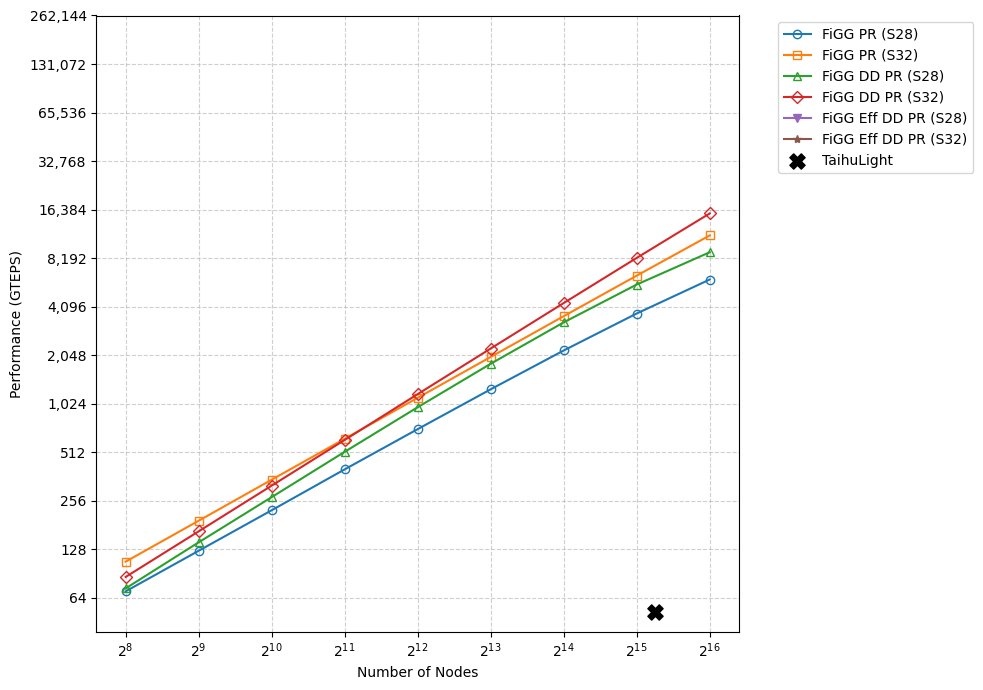

In [ ]:
# 1. Load Data
worksheet = sh.worksheet("PageRank")

data = worksheet.get_all_values()
df_pr = pd.DataFrame(data)

# 2. Extract series
x_nodes = pd.to_numeric(df_pr.iloc[1, 2:16], errors='coerce').values
lines = {
    'FiGG PR (S28)': df_pr.iloc[11, 2:16],
    'FiGG PR (S32)': df_pr.iloc[12, 2:16],
    'FiGG DD PR (S28)': df_pr.iloc[13, 2:16],
    'FiGG DD PR (S32)': df_pr.iloc[14, 2:16],
    'FiGG Eff DD PR (S28)': df_pr.iloc[17, 2:16],
    'FiGG Eff DD PR (S32)': df_pr.iloc[18, 2:16]
}

# 3. Plotting
plt.figure(figsize=(10, 7))
markers = ['o', 's', '^', 'D', 'v', '*']
for (label, data), m in zip(lines.items(), markers):
    plt.plot(x_nodes, pd.to_numeric(data), marker=m, label=label, markerfacecolor='none' if m in ['o','s','^','D'] else None)

# TaihuLight Point
plt.scatter(39000, 52, label='TaihuLight', color='black', marker='X', s=120, zorder=5)

# 4. Axes & Formatter
plt.xscale('log', base=2)
plt.yscale('log', base=2)

# Format labels with commas
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))

# Align horizontal grid to powers of 2
y_vals = pd.concat([pd.to_numeric(d) for d in lines.values()])
y_ticks = [2**i for i in range(int(np.floor(np.log2(y_vals.min()))), int(np.ceil(np.log2(y_vals.max()))) + 1)]
plt.yticks(y_ticks)

plt.xlabel('Number of Nodes')
plt.ylabel('Performance (GTEPS)')
plt.grid(True, which='major', axis='both', linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()